In [1]:
import sys
import os
sys.path.append(os.path.abspath("../src"))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
from datetime import datetime
from preprocessing import load_data
from classicalmodels import LogisticRegression, KNN, LinearSVM, KernelPerceptron, BinaryCrossEntropyLoss, BoostedTree, XGBoost,XGBoostSigmoid


In [2]:
def run_experiments(X_train, y_train, X_test, y_test):
    results = []
    params = {

    'learning_rate': 0.1,
    'max_depth': 3,
    'subsample': 0.8,
    'min_child_weight': 1,
    'reg_lambda': 1,
    'gamma': 0
}

    models = [
        (LogisticRegression(), "Logistic Regression"),
        (KNN(k=5), "KNN"),
        (LinearSVM(learning_rate=0.001, lambda_param=0.01, n_iters=1000), "Linear SVM"),
        # ADDED: RBF Kernel SVM with a stable learning rate, small penalty, and standard gamma
        (KernelPerceptron(kernel='poly', degree=2,coef0=2,epochs=100), "poly Kernel SVM"),
        (XGBoostSigmoid(params), "XGBoost")
        
    ]
    
    for model, name in models:
        print(f"Optimizing parameters and fitting weights for: {name}...")
        model.fit(X_train, y_train)
        
        # Calls the unified dictionary evaluator component
        result = model.evaluate(X_test, y_test)
        results.append(result)
        
    return results

In [3]:
def print_results(results):
    print("\n" + "="*30 + "\n   MODEL COMPARISON METRICS\n" + "="*30 + "\n")

    os.makedirs("../results", exist_ok=True)
    with open("../results/experiment_log.txt", "a") as f:
        f.write("\n" + "="*40 + "\n")
        f.write(f"Experiment Run Timestamp: {datetime.now()}\n")
        f.write("="*40 + "\n\n")

        for r in results:
            # 1. Terminal Printing (Separated lines prevent VS Code output truncation)
            print(f"Model Architecture: {r['model']}")
            print(f"Test Accuracy     : {r['accuracy']:.4f}")
            print(f"Precision Score   : {r['precision']:.4f}")
            print(f"Recall (Sensitivity): {r['recall']:.4f}")
            print(f"F1 Balanced Score : {r['f1_score']:.4f}")
            print("Confusion Matrix Array:")
            # Forcing standard string transformation makes numpy arrays display cleanly
            print(np.array2string(r['confusion_matrix']))
            print("----------------------------------------\n")

            # 2. Text File Logging (Keeps your clean, unified format in the log file)
            output = (
                f"Model Architecture: {r['model']}\n"
                f"Test Accuracy     : {r['accuracy']:.4f}\n"
                f"Precision Score   : {r['precision']:.4f}\n"
                f"Recall (Sensitivity): {r['recall']:.4f}\n"
                f"F1 Balanced Score : {r['f1_score']:.4f}\n"
                f"Confusion Matrix Array:\n{np.array2string(r['confusion_matrix'])}\n"
                f"----------------------------------------\n"
            )
            f.write(output)

In [4]:

def plot_model_comparison(results):
    models = [r['model'] for r in results]
    accuracy_scores = [r['accuracy'] for r in results]
    f1_scores = [r['f1_score'] for r in results]

    x = np.arange(len(models))  
    width = 0.35

    plt.figure(figsize=(10, 6))

    # Plot double comparison bars side-by-side cleanly
    plt.bar(x - width/2, accuracy_scores, width=width, label='Accuracy', color='#4d79ff', edgecolor='k')
    plt.bar(x + width/2, f1_scores, width=width, label='F1 Score', color='#ff4d4d', edgecolor='k')

    plt.xticks(x, models, fontsize=10, fontweight='bold')
    plt.ylabel("Performance Score Scale (0.0 - 1.0)", fontsize=11)
    plt.title("Comparative Performance Analysis: Baseline Linear vs. Non-Linear Models", fontsize=12, fontweight='bold', pad=15)
    plt.ylim(0, 1.05)
    plt.grid(axis='y', linestyle=':', alpha=0.6)
    
    # MODIFIED: Changed from 'lower right' to 'lower left' 
    # This prevents the legend from blocking your new RBF bars!
    plt.legend(loc='lower left', frameon=True, shadow=True)

    os.makedirs("../figures", exist_ok=True)
    plt.savefig("../figures/model_comparison.png", dpi=300)
    plt.show()

In [5]:
def save_metrics_table(results):
    data = []
    for r in results:
        data.append({
            "Model": r['model'],
            "Accuracy": r['accuracy'],
            "Precision": r['precision'],
            "Recall": r['recall'],
            "F1 Score": r['f1_score']
        })

    df = pd.DataFrame(data)
    df.to_csv("../results/metrics_table.csv", index=False)
    print("[Success] Centralized results written to: ../results/metrics_table.csv")

Optimizing parameters and fitting weights for: Logistic Regression...
Optimizing parameters and fitting weights for: KNN...
Optimizing parameters and fitting weights for: Linear SVM...
Optimizing parameters and fitting weights for: poly Kernel SVM...
Kernel stats: 0.3167034990878937 17.78791339159011 4.079705223902319
Training finished after 100 epochs
Support vectors: 370
Optimizing parameters and fitting weights for: XGBoost...

   MODEL COMPARISON METRICS

Model Architecture: Logistic Regression
Test Accuracy     : 0.8650
Precision Score   : 0.8696
Recall (Sensitivity): 0.8421
F1 Balanced Score : 0.8556
Confusion Matrix Array:
[[93 12]
 [15 80]]
----------------------------------------

Model Architecture: KNN
Test Accuracy     : 0.7900
Precision Score   : 0.8118
Recall (Sensitivity): 0.7263
F1 Balanced Score : 0.7667
Confusion Matrix Array:
[[89 16]
 [26 69]]
----------------------------------------

Model Architecture: Linear SVM
Test Accuracy     : 0.8400
Precision Score   : 0.86

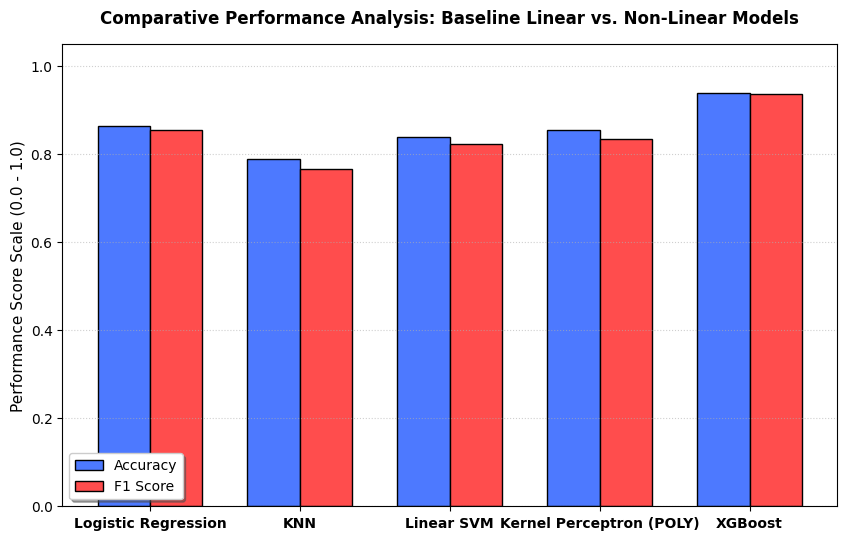

[Success] Centralized results written to: ../results/metrics_table.csv


In [6]:
X_train, X_test, y_train, y_test = load_data("../data/disease_prediction.csv")


# 2. Trigger your experimental functions
results = run_experiments(X_train, y_train, X_test, y_test)
print_results(results)
plot_model_comparison(results)
save_metrics_table(results)


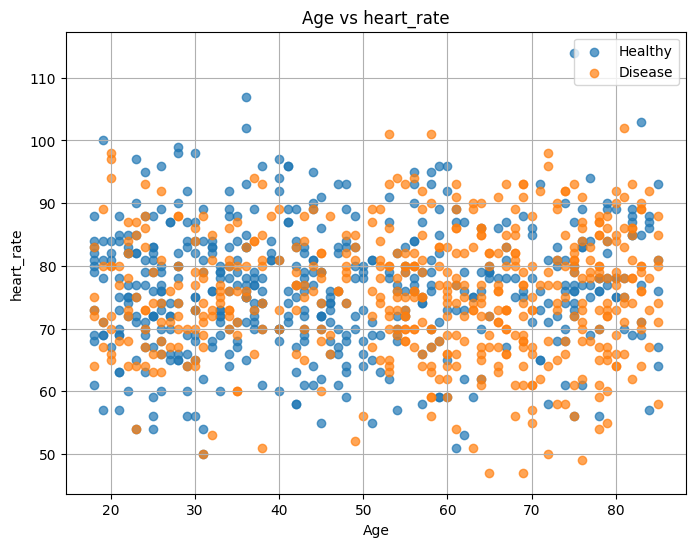

In [7]:
plt.figure(figsize=(8,6))
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/disease_prediction.csv")
healthy = df[df["disease"] == "No"]
disease = df[df["disease"] == "Yes"]

plt.scatter(
    healthy["age"],
    healthy["heart_rate"],
    label="Healthy",
    alpha=0.7
)

plt.scatter(
    disease["age"],
    disease["heart_rate"],
    label="Disease",
    alpha=0.7
)

plt.xlabel("Age")
plt.ylabel("heart_rate")
plt.title("Age vs heart_rate")

plt.legend()
plt.grid(True)

plt.show()

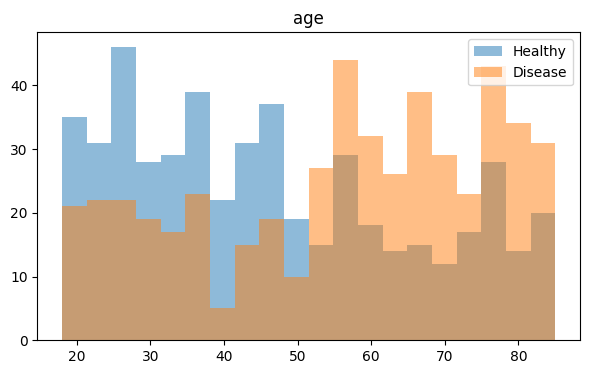

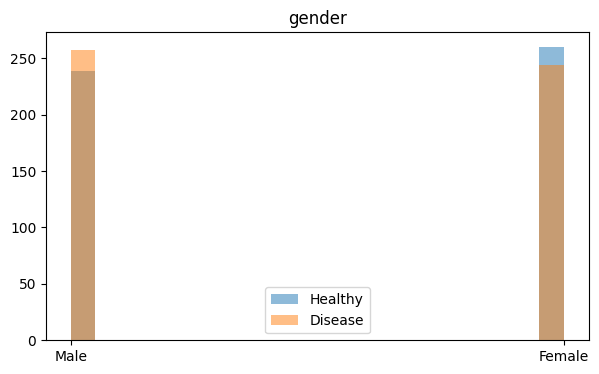

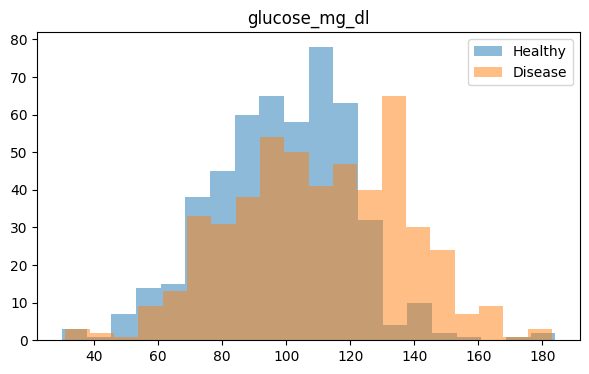

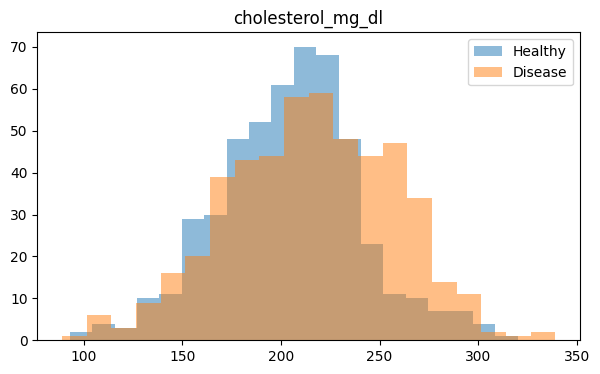

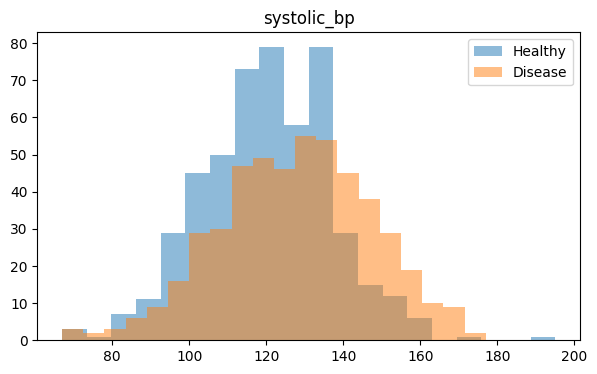

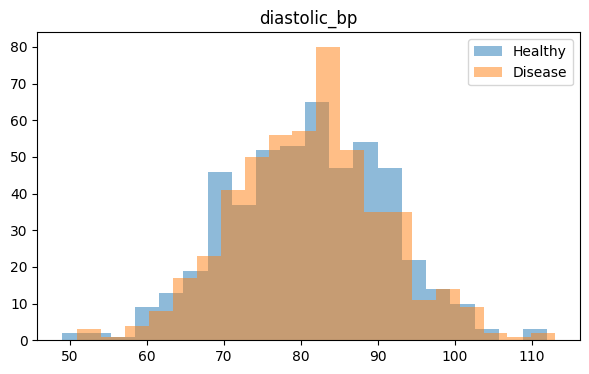

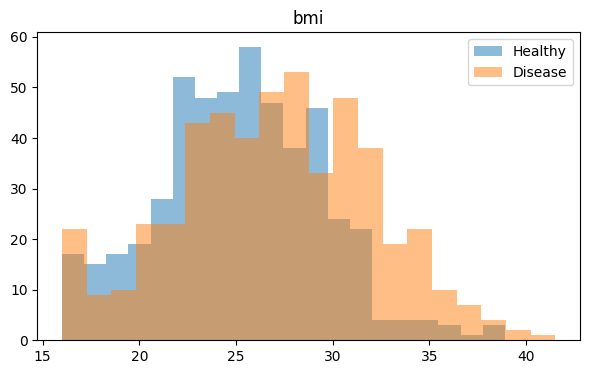

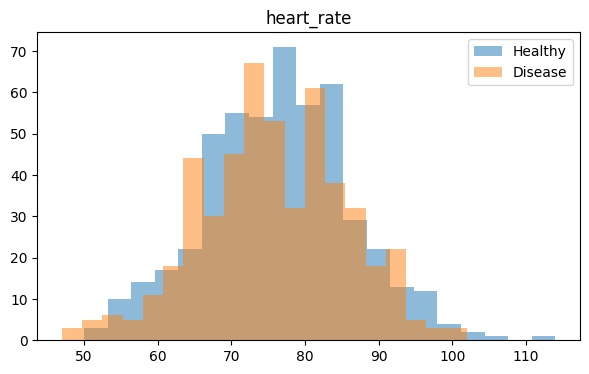

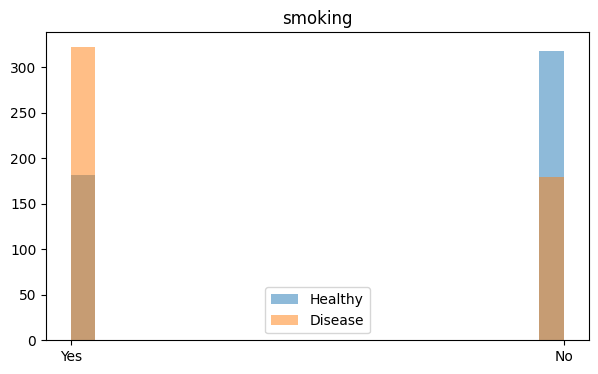

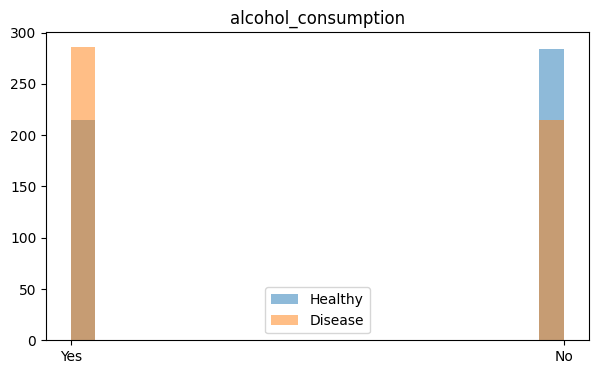

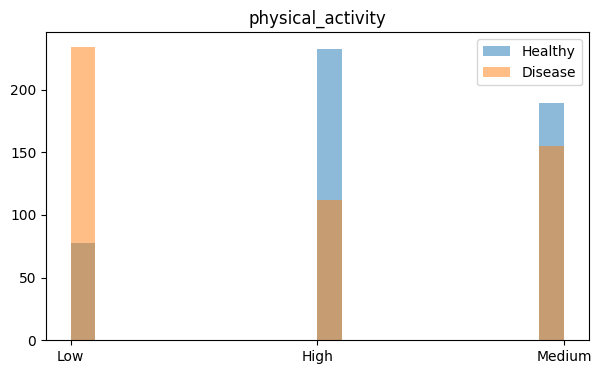

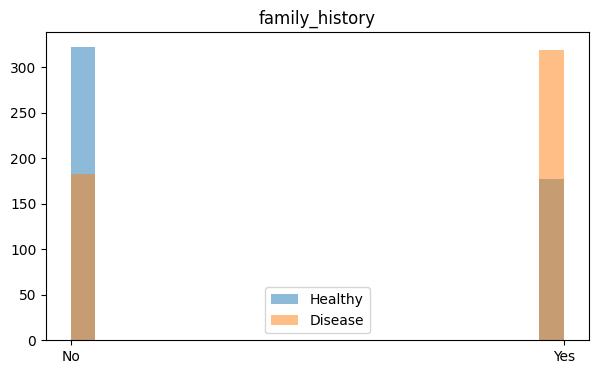

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/disease_prediction.csv")

target = "disease"

features = [c for c in df.columns if c not in ['disease','patient_id']  ]

for feature in features:

    plt.figure(figsize=(7,4))

    plt.hist(
        df[df[target] == "No"][feature],
        bins=20,
        alpha=0.5,
        label="Healthy"
    )

    plt.hist(
        df[df[target] == "Yes"][feature],
        bins=20,
        alpha=0.5,
        label="Disease"
    )

    plt.title(feature)
    plt.legend()

    plt.show()